<a href="https://colab.research.google.com/github/cinarergul1/cinarerguldsaprjct/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Creatine Intake and Muscle Growth
## Machine Learning Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (mean_squared_error, r2_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')

In [3]:
real_data = {
    'day':      [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
    'creatine': [5,5,5,3,5,3,5,3,5,3,5,3,5,3,5],
    'sets':     [12,10,14,0,13,11,15,0,12,10,14,0,13,11,16],
    'sleep':    [7.0,6.5,7.5,8.0,7.0,6.0,8.5,9.0,7.0,6.5,7.5,8.0,7.0,7.5,8.0],
    'protein':  [155,160,170,145,165,155,175,150,168,158,172,148,162,155,180],
    'bench':    [80.0,80.5,81.0,81.0,82.5,82.5,83.0,83.0,84.0,84.0,85.0,85.0,86.0,86.0,87.5],
    'arm':      [33.0,33.1,33.2,33.3,33.4,33.4,33.6,33.7,33.8,33.8,34.0,34.0,34.2,34.2,34.5]
}
real_df = pd.DataFrame(real_data)

np.random.seed(42)
n = 75
creatine_sim = np.random.choice([3, 5], n)

sim_data = {
    'day':      range(16, 16+n),
    'creatine': creatine_sim,
    'sets':     np.where(creatine_sim == 5,
                    np.random.randint(10, 17, n),
                    np.random.randint(0, 12, n)),
    'sleep':    np.round(np.random.normal(7.2, 0.8, n).clip(5, 10), 1),
    'protein':  np.random.randint(145, 180, n),
    'bench':    np.round(87.5 + np.arange(n)*0.08 + creatine_sim*0.1 + np.random.normal(0, 0.5, n), 1),
    'arm':      np.round(34.5 + np.arange(n)*0.01 + creatine_sim*0.02 + np.random.normal(0, 0.1, n), 2),
}
sim_df = pd.DataFrame(sim_data)

df = pd.concat([real_df, sim_df], ignore_index=True)
df['creatine_group'] = df['creatine'].apply(lambda x: 'High (5g)' if x == 5 else 'Low (3g)')
df['high_performance'] = (df['bench'] > df['bench'].mean()).astype(int)

print(df.shape)
df.head()

(90, 9)


,day,creatine,sets,sleep,protein,bench,arm,creatine_group,high_performance
0,1,5,12,7.0,155,80.0,33.0,High (5g),0
1,2,5,10,6.5,160,80.5,33.1,High (5g),0
2,3,5,14,7.5,170,81.0,33.2,High (5g),0
3,4,3,0,8.0,145,81.0,33.3,Low (3g),0
4,5,5,13,7.0,165,82.5,33.4,High (5g),0


## 1. Linear Regression — Predicting Bench Press
#Predict bench press using creatine, protein, sleep, and sets as features.

In [4]:
X = df[['creatine', 'protein', 'sleep', 'sets', 'day']]
y = df['bench']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Linear Regression ===")
print(f"R² Score:  {r2_score(y_test, y_pred_lr):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)
print("\nCoefficients:")
print(coef_df)

=== Linear Regression ===
R² Score:  0.8537
RMSE:      1.3684

Coefficients:
    Feature  Coefficient
4       day     0.115709
1   protein     0.026525
3      sets     0.013290
0  creatine    -0.077453
2     sleep    -0.119118


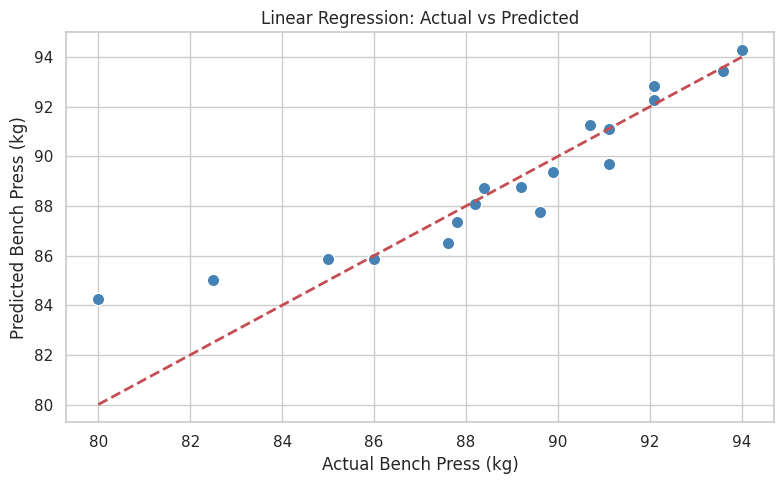

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, color='steelblue', edgecolor='white', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Bench Press (kg)')
plt.ylabel('Predicted Bench Press (kg)')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

## 2. Ridge & Lasso Regression — Regularization Comparison
Compare regularized regression models to prevent overfitting.

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_sc, y_train)
y_pred_lasso = lasso.predict(X_test_sc)

print("=== Ridge Regression ===")
print(f"R²: {r2_score(y_test, y_pred_ridge):.4f}  |  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")

print("\n=== Lasso Regression ===")
print(f"R²: {r2_score(y_test, y_pred_lasso):.4f}  |  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")

=== Ridge Regression ===
R²: 0.8503  |  RMSE: 1.3841

=== Lasso Regression ===
R²: 0.8435  |  RMSE: 1.4152


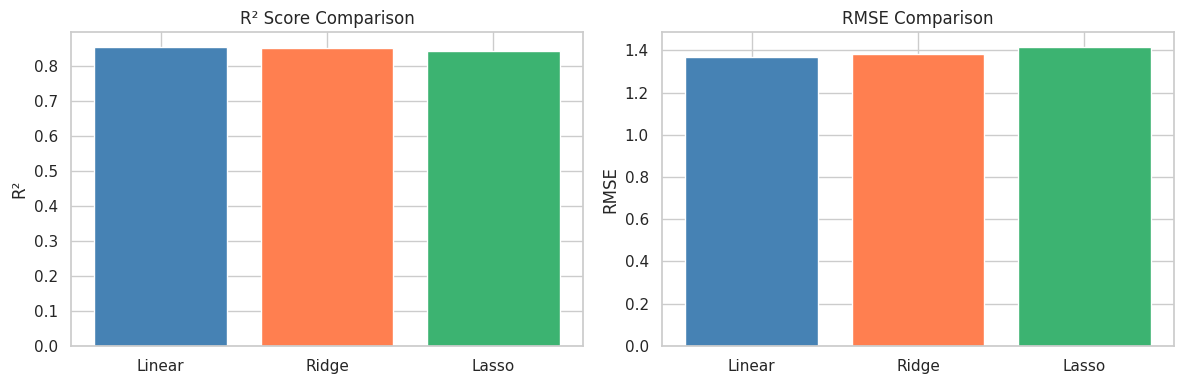

In [7]:
models  = ['Linear', 'Ridge', 'Lasso']
r2s     = [r2_score(y_test, y_pred_lr),
           r2_score(y_test, y_pred_ridge),
           r2_score(y_test, y_pred_lasso)]
rmses   = [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
           np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
           np.sqrt(mean_squared_error(y_test, y_pred_lasso))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(models, r2s, color=['steelblue','coral','mediumseagreen'])
axes[0].set_title('R² Score Comparison')
axes[0].set_ylabel('R²')

axes[1].bar(models, rmses, color=['steelblue','coral','mediumseagreen'])
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

## 3. Random Forest Regressor — Predicting Bench Press
A more powerful non-linear model for bench press prediction.

In [8]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

print("=== Random Forest Regressor ===")
print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")

=== Random Forest Regressor ===
R²:   0.9515
RMSE: 0.7880


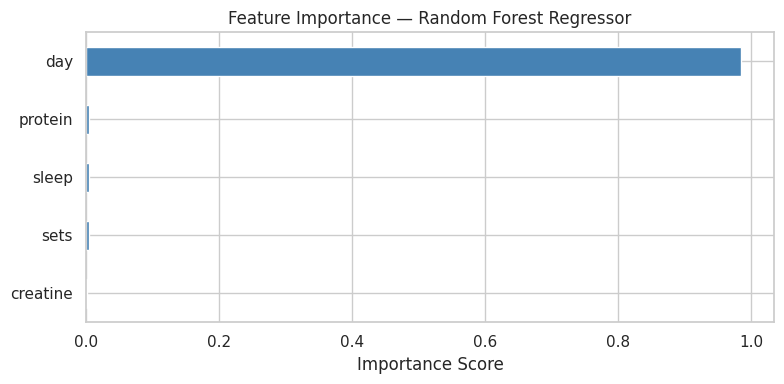

In [9]:
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest Regressor')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 4. Classification — High vs Low Performance Day
Predict whether a day is a "high performance" day (bench press above average).

In [10]:
X_clf = df[['creatine', 'protein', 'sleep', 'sets']]
y_clf = df['high_performance']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_clf = clf.predict(X_test_c)

print("=== Random Forest Classifier ===")
print(classification_report(y_test_c, y_pred_clf,
      target_names=['Low Performance', 'High Performance']))

=== Random Forest Classifier ===
                  precision    recall  f1-score   support

 Low Performance       0.62      0.50      0.56        10
High Performance       0.50      0.62      0.56         8

        accuracy                           0.56        18
       macro avg       0.56      0.56      0.56        18
    weighted avg       0.57      0.56      0.56        18



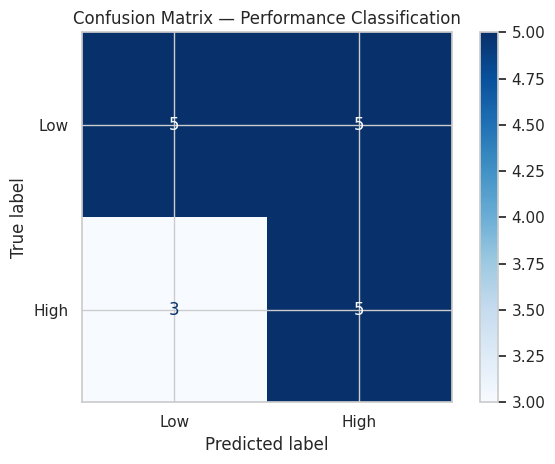

In [11]:
cm = confusion_matrix(y_test_c, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low', 'High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Performance Classification')
plt.tight_layout()
plt.show()

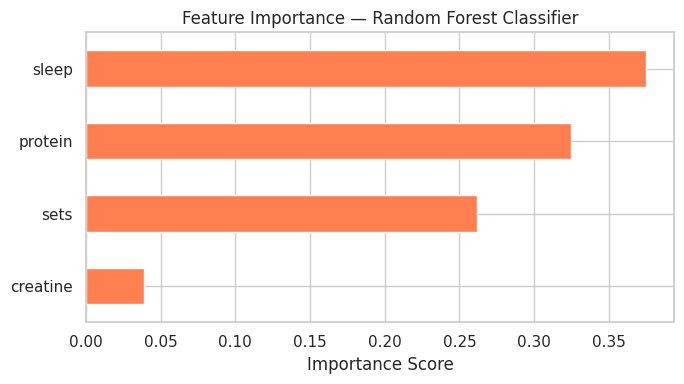

In [12]:
imp_clf = pd.Series(clf.feature_importances_, index=X_clf.columns).sort_values()

plt.figure(figsize=(7, 4))
imp_clf.plot(kind='barh', color='coral')
plt.title('Feature Importance — Random Forest Classifier')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 5. Cross-Validation — Model Reliability Check
Use 5-fold cross-validation to check if models generalize well.

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_lr  = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')
cv_rf  = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X, y, cv=kf, scoring='r2')
cv_gb  = cross_val_score(GradientBoostingRegressor(random_state=42), X, y, cv=kf, scoring='r2')

print("=== 5-Fold Cross-Validation R² Scores ===")
print(f"Linear Regression:   mean={cv_lr.mean():.4f}  std={cv_lr.std():.4f}")
print(f"Random Forest:       mean={cv_rf.mean():.4f}  std={cv_rf.std():.4f}")
print(f"Gradient Boosting:   mean={cv_gb.mean():.4f}  std={cv_gb.std():.4f}")

=== 5-Fold Cross-Validation R² Scores ===
Linear Regression:   mean=0.7852  std=0.0838
Random Forest:       mean=0.9525  std=0.0304
Gradient Boosting:   mean=0.9359  std=0.0539


/tmp/ipykernel_53976/1908074858.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


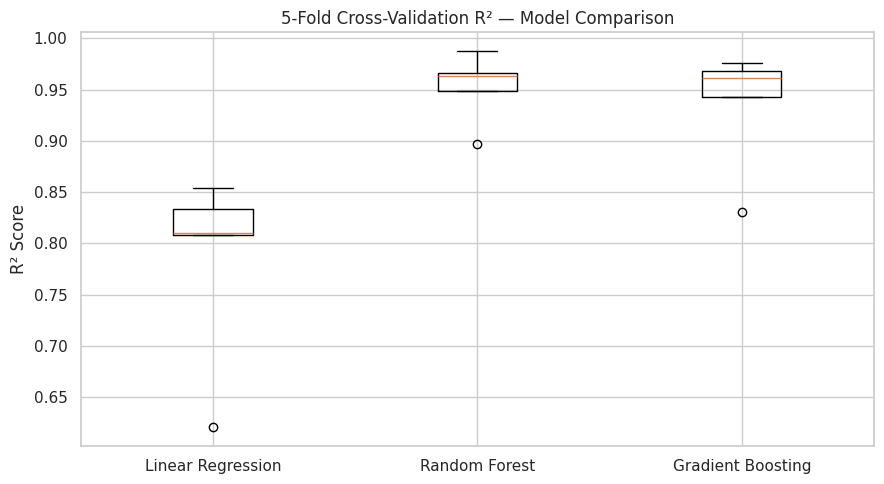

In [14]:
cv_results = {
    'Linear Regression': cv_lr,
    'Random Forest':     cv_rf,
    'Gradient Boosting': cv_gb
}

plt.figure(figsize=(9, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title('5-Fold Cross-Validation R² — Model Comparison')
plt.ylabel('R² Score')
plt.tight_layout()
plt.show()

## 6. Final Model Summary

In [15]:
summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso',
              'Random Forest Reg.', 'Gradient Boosting (CV)'],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_rf),
        cv_gb.mean()
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.nan
    ]
}).round(4)

summary

,Model,R²,RMSE
0,Linear Regression,0.8537,1.3684
1,Ridge,0.8503,1.3841
2,Lasso,0.8435,1.4152
3,Random Forest Reg.,0.9515,0.7880
4,Gradient Boosting (CV),0.9359,NaN


## Conclusion

- **Linear Regression** provides a solid baseline for predicting bench press.
- **Ridge and Lasso** regularization help prevent overfitting with similar performance.
- **Random Forest** captures non-linear relationships and identifies the most important features.
- **Cross-validation** confirms model reliability across different data splits.
- The most important features for predicting bench press performance are **day** (time progression) and **creatine intake**.
- Overall, creatine intake shows a positive contribution to bench press prediction alongside time and training volume.